# 07b - Redes neurais temporais: TCN e GRU

Este notebook acrescenta uma nova familia de modelos ao projeto **sem abrir 2025**.

A ideia central e diferente do XGBoost. O XGBoost recebe uma fotografia resumida do passado: nivel atual, chuva acumulada em 1 h/3 h/6 h, lags etc. Aqui entregamos uma **sequencia ordenada das ultimas horas**, como um pequeno filme da bacia.

Para cada horario `t`, a rede recebe, por exemplo, os 36 registros das ultimas 6 h:

\[
X_{t-350min},\ldots,X_{t-10min},X_t,
\]

com niveis, chuva, radar e indicadores de dados faltantes. Ela produz quatro saidas simultaneas:

\[
\widehat{\Delta H}_{2h},\qquad
P(\Delta H_{2h}\ge1m),\qquad
P(\Delta H_{2h}\ge2m),\qquad
P(\Delta H_{2h}\ge3m).
\]

Isso e importante porque os experimentos tabulares mostraram duas tarefas distintas:

- **magnitude**: quantos centimetros o rio deve subir;
- **severidade/alerta**: ha risco de uma subida realmente grande?

## Modelos deste notebook

1. **TCN (Temporal Convolutional Network)** - convolucoes causais ao longo do tempo, com dilatacoes para enxergar diferentes escalas temporais.
2. **GRU (Gated Recurrent Unit)** - rede recorrente com estado interno, projetada para aprender dependencias temporais.

Os dois usam exatamente os mesmos dados e os mesmos splits para uma comparacao justa.

> **Regra metodologica:** 2023 escolhe/valida. 2024 compara os candidatos. 2025 continua completamente reservado para o notebook 08.

## 0. Dependencias

O pacote novo usa PyTorch. No terminal com o ambiente `(.venv)`, caso necessario:

```powershell
python -m pip install torch
```

As demais bibliotecas ja eram usadas pelo projeto. Em Windows/Jupyter, os `DataLoader`s abaixo usam `num_workers=0` para evitar problemas de multiprocessing.

In [1]:
from pathlib import Path
import sys, json, math, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
OUTPUTS = ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"
PREDICTIONS = OUTPUTS / "predictions"
REPORTS = OUTPUTS / "reports"

for p in [MODELS, TABLES, FIGURES, PREDICTIONS, REPORTS]:
    p.mkdir(parents=True, exist_ok=True)

# Permite importar ROOT/utils/temporal_models.py.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.temporal_models import (
    TemporalPreprocessor,
    TemporalPreprocessorState,
    SequenceDataset,
    TCNMultiTask,
    GRUMultiTask,
    TrainingConfig,
    build_temporal_frame,
    choose_device,
    valid_sequence_indices,
    train_model,
    predict_model,
    choose_probability_threshold,
    point_regression_metrics,
    classification_metrics,
    severity_metrics,
    conformal_intervals,
    save_model_definition,
)

import torch
from torch.utils.data import DataLoader

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", choose_device())

Python: c:\Users\osmar\Área de Trabalho\Field-Project\.venv\Scripts\python.exe
PyTorch: 2.13.0+cpu
Device: cpu


## 1. Configuracao do experimento

A configuracao principal usa **6 h de historico**. Como os dados sao de 10 em 10 minutos, isso equivale a 36 passos temporais.

Por que comecar por 6 h? Os atrasos empiricos das estacoes a montante ficaram na ordem de dezenas de minutos, e 6 h ja cobre varias vezes essas escalas. Se as redes mostrarem ganho, uma ablation 6 h vs 12 h pode ser feita depois sem usar 2025.

`TRAIN_STRIDE=2` usa um exemplo de treino a cada 20 minutos. Isso reduz a enorme redundancia entre janelas consecutivas de 10 minutos, sem alterar a avaliacao: validacao e teste continuam usando todos os timestamps disponiveis.

In [2]:
QUICK_RUN = False
LOOKBACK_STEPS = 36      # 6 horas
HORIZON_MIN = 120
TRAIN_STRIDE = 6 if QUICK_RUN else 2
BATCH_SIZE = 256 if QUICK_RUN else 512
MAX_EPOCHS = 5 if QUICK_RUN else 30
PATIENCE = 2 if QUICK_RUN else 6
SEED = 42

RUN_TCN = True
RUN_GRU = True

print(f"Lookback: {LOOKBACK_STEPS} passos = {LOOKBACK_STEPS*10/60:.1f} h")
print("Train stride:", TRAIN_STRIDE)

Lookback: 36 passos = 6.0 h
Train stride: 2


## 2. Construindo o "filme" de entrada

Para as redes temporais, usamos principalmente **medicoes instantaneas**:

- nivel da 413;
- niveis 1000490, 143 e 283;
- chuva dos 23 pluviometros;
- resumos instantaneos do radar (media, maximo, percentis, fracao molhada etc., conforme disponiveis);
- hora do dia e epoca do ano em forma ciclica.

Nao entregamos as dezenas de acumulados de 1 h/3 h/6 h do XGBoost, porque queremos que a rede aprenda parte dessas estruturas diretamente da sequencia.

### Dados faltantes

Um ponto importante: **faltante nao e igual a zero**. O pre-processador adiciona um canal binario `missing__...` para cada sensor. Assim, mesmo quando o valor precisa ser preenchido numericamente, a rede sabe que aquela observacao original estava ausente.

In [3]:
master_path = PROCESSED / "master_base.parquet"
features_path = PROCESSED / "features_causal.parquet"
radar_path = PROCESSED / "radar_features_basic.parquet"

for p in [master_path, features_path, radar_path]:
    if not p.exists():
        raise FileNotFoundError(
            f"Arquivo ausente: {p}. Rode os notebooks anteriores (especialmente 02, 03 e 06) antes do 07b."
        )

master = pd.read_parquet(master_path).sort_index()
features = pd.read_parquet(features_path).sort_index()
radar = pd.read_parquet(radar_path).sort_index()

if radar.index.has_duplicates:
    radar = radar.groupby(level=0).mean(numeric_only=True).sort_index()

raw_temporal, channel_groups = build_temporal_frame(master, radar=radar)

TARGET = "target_delta_120m"
target = features[TARGET].reindex(raw_temporal.index)
split = features["split"].reindex(raw_temporal.index)

print("Linhas:", len(raw_temporal))
print("Canais brutos:", raw_temporal.shape[1])
print("Por grupo:", {k: len(v) for k, v in channel_groups.items()})
display(raw_temporal.head(3))

Linhas: 525744
Canais brutos: 38
Por grupo: {'stage': 4, 'rain': 23, 'radar': 7, 'time': 4}


,stage_413,stage_1000490,stage_143,stage_283,rain_143,rain_275,rain_279,rain_280,rain_283,rain_413,...,radar_max,radar_p75,radar_p90,radar_p95,radar_wet_fraction,radar_cells_available,time_sin_day,time_cos_day,time_sin_year,time_cos_year
time,,,,,,,,,,,,,,,,,,,,,
2015-04-01 00:00:00,716.682007,754.705017,733.299988,722.155029,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,434.0,0.000000,1.000000,0.999986,0.005376
2015-04-01 00:10:00,716.682007,754.703979,733.299988,722.161011,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,434.0,0.043619,0.999048,0.999986,0.005376
2015-04-01 00:20:00,716.671021,754.705994,733.304993,722.166992,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,434.0,0.087156,0.996195,0.999986,0.005376


## 3. Pre-processamento sem vazamento temporal

As medias, desvios e medianas usados para padronizar os dados sao calculados **somente no treino (2015-2022)**.

- niveis: `forward-fill` causal de no maximo 1 h e depois mediana do treino;
- chuva/radar: mediana do treino, **sem forward-fill**, mais mascara de faltante;
- alvo de regressao: tambem e padronizado usando apenas o treino.

Isso evita usar informacao de 2023/2024 para preparar os exemplos de treinamento.

In [4]:
train_mask = split.eq("train") & target.notna()

pre = TemporalPreprocessor(channel_groups, stage_ffill_limit=6)
pre.fit(raw_temporal, train_mask=train_mask, target=target)
scaled = pre.transform(raw_temporal)

matrix = scaled.to_numpy(dtype="float32")
y_raw = target.to_numpy(dtype="float32")
y_scaled = pre.transform_target(y_raw)

pre.state.to_json(MODELS / "temporal_preprocessor_v6.json")

print("Canais apos mascaras de missingness:", matrix.shape[1])
print("Target mean treino:", pre.state.target_mean)
print("Target std treino:", pre.state.target_std)

Canais apos mascaras de missingness: 72
Target mean treino: -1.4630912119173445e-05
Target std treino: 0.4386112093925476


## 4. Janelas de treino, validacao e teste

Cada amostra da rede termina no horario da previsao `t` e olha apenas para tras. O alvo continua sendo o que realmente aconteceu nas duas horas seguintes.

O primeiro horario de 2023 pode usar as ultimas horas de 2022 como contexto. Isso **nao e vazamento**: em uma operacao real, essas observacoes passadas estariam disponiveis no instante da previsao.

In [5]:
idx_train = valid_sequence_indices(raw_temporal.index, split, target, "train", LOOKBACK_STEPS, stride=TRAIN_STRIDE)
idx_valid = valid_sequence_indices(raw_temporal.index, split, target, "validation", LOOKBACK_STEPS, stride=1)
idx_test = valid_sequence_indices(raw_temporal.index, split, target, "test_2024", LOOKBACK_STEPS, stride=1)

print("Treino:", len(idx_train))
print("Validacao 2023:", len(idx_valid))
print("Teste desenvolvimento 2024:", len(idx_test))

train_ds = SequenceDataset(matrix, y_scaled, y_raw, idx_train, LOOKBACK_STEPS)
valid_ds = SequenceDataset(matrix, y_scaled, y_raw, idx_valid, LOOKBACK_STEPS)
test_ds = SequenceDataset(matrix, y_scaled, y_raw, idx_test, LOOKBACK_STEPS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

xb, yr, yc, yraw_b, pos = next(iter(train_loader))
print("Shape de um batch:", tuple(xb.shape), "= batch x tempo x canais")
print("Saidas de classificacao:", tuple(yc.shape), "(>=1m, >=2m, >=3m)")

Treino: 202972
Validacao 2023: 45981
Teste desenvolvimento 2024: 45955
Shape de um batch: (512, 36, 72) = batch x tempo x canais
Saidas de classificacao: (512, 3) (>=1m, >=2m, >=3m)


## 5. Funcao auxiliar para treinar um modelo

A regressao usa **Huber loss** e recebe um peso maior quando a subida real supera 1, 2 ou 3 m. As tres classificacoes usam `BCEWithLogitsLoss` com compensacao automatica para raridade dos eventos.

Isso nao garante que os extremos serao resolvidos; apenas impede que as centenas de milhares de momentos tranquilos dominem totalmente o treinamento.

In [6]:
DEVICE = choose_device()
INPUT_DIM = matrix.shape[1]

histories = {}
predictions = {}
model_objects = {}


def fit_and_predict(kind):
    kind = kind.upper()
    if kind == "TCN":
        model = TCNMultiTask(INPUT_DIM, channels=(64,64,96,96), kernel_size=3, dropout=0.15)
        definition = dict(model_kind="TCN", input_dim=INPUT_DIM, channels=[64,64,96,96], kernel_size=3, dropout=0.15)
    elif kind == "GRU":
        model = GRUMultiTask(INPUT_DIM, hidden_dim=96, num_layers=2, dropout=0.15)
        definition = dict(model_kind="GRU", input_dim=INPUT_DIM, hidden_dim=96, num_layers=2, dropout=0.15)
    else:
        raise ValueError(kind)

    cfg = TrainingConfig(
        model_name=kind,
        lookback_steps=LOOKBACK_STEPS,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        learning_rate=1e-3,
        weight_decay=1e-4,
        classification_loss_weight=0.35,
        seed=SEED,
    )
    ckpt = MODELS / f"{kind.lower()}_multitask_dev_v6.pt"
    y_train_for_weights = y_raw[idx_train]

    hist = train_model(model, train_loader, valid_loader, y_train_for_weights, cfg, ckpt, device=DEVICE)
    pd.DataFrame(hist).to_csv(TABLES / f"{kind.lower()}_training_history_v6.csv", index=False)

    # A funcao train_model ja recarrega o melhor checkpoint no objeto model.
    p_valid = predict_model(model, valid_loader, pre, raw_temporal.index, device=DEVICE)
    p_test = predict_model(model, test_loader, pre, raw_temporal.index, device=DEVICE)

    Path(MODELS / f"{kind.lower()}_definition_v6.json").write_text(json.dumps(definition, indent=2), encoding="utf-8")
    return model, hist, p_valid, p_test

## 6. TCN

In [7]:
if RUN_TCN:
    t0 = time.time()
    tcn_model, tcn_history, tcn_valid, tcn_test = fit_and_predict("TCN")
    histories["TCN"] = tcn_history
    predictions["TCN"] = {"validation": tcn_valid, "test_2024": tcn_test}
    model_objects["TCN"] = tcn_model
    print(f"TCN concluida em {(time.time()-t0)/60:.1f} min")

[TCN] epoch 01 | train=0.3561 | valid=0.2868 | lr=1.00e-03
[TCN] epoch 02 | train=0.2878 | valid=0.2910 | lr=1.00e-03
[TCN] epoch 03 | train=0.2670 | valid=0.2918 | lr=1.00e-03
[TCN] epoch 04 | train=0.2565 | valid=0.2879 | lr=5.00e-04
[TCN] epoch 05 | train=0.2313 | valid=0.3003 | lr=5.00e-04
[TCN] epoch 06 | train=0.2236 | valid=0.3032 | lr=5.00e-04
[TCN] epoch 07 | train=0.2137 | valid=0.3332 | lr=2.50e-04
Early stopping at epoch 7; best validation loss=0.2868
TCN concluida em 23.7 min


## 7. GRU

In [8]:
if RUN_GRU:
    t0 = time.time()
    gru_model, gru_history, gru_valid, gru_test = fit_and_predict("GRU")
    histories["GRU"] = gru_history
    predictions["GRU"] = {"validation": gru_valid, "test_2024": gru_test}
    model_objects["GRU"] = gru_model
    print(f"GRU concluida em {(time.time()-t0)/60:.1f} min")

[GRU] epoch 01 | train=0.3187 | valid=0.2825 | lr=1.00e-03
[GRU] epoch 02 | train=0.2625 | valid=0.2733 | lr=1.00e-03
[GRU] epoch 03 | train=0.2464 | valid=0.2725 | lr=1.00e-03
[GRU] epoch 04 | train=0.2310 | valid=0.2822 | lr=1.00e-03
[GRU] epoch 05 | train=0.2196 | valid=0.2797 | lr=1.00e-03
[GRU] epoch 06 | train=0.2103 | valid=0.2891 | lr=5.00e-04
[GRU] epoch 07 | train=0.1875 | valid=0.2937 | lr=5.00e-04
[GRU] epoch 08 | train=0.1774 | valid=0.3113 | lr=5.00e-04
[GRU] epoch 09 | train=0.1705 | valid=0.3578 | lr=2.50e-04
Early stopping at epoch 9; best validation loss=0.2725
GRU concluida em 13.2 min


## 8. Escolha dos limiares de alerta em 2023

A rede fornece probabilidades. Ainda precisamos decidir a partir de qual probabilidade emitimos um alerta.

Para cada severidade (>=1 m, >=2 m e >=3 m), escolhemos o limiar que maximiza **F2 em 2023**. O F2 da mais peso ao recall do que a precision, porque perder um evento severo tende a ser mais grave do que gerar algum falso alerta.

Depois esses limiares ficam congelados e sao aplicados a 2024.

In [9]:
threshold_rows = []
alert_rows = []
point_rows = []
severity_rows = []
conformal_rows = []

for model_name, pp in predictions.items():
    v = pp["validation"].copy()
    te = pp["test_2024"].copy()

    # Regressao global
    m = point_regression_metrics(te["target_delta_120m"].to_numpy(), te["pred_delta_120m"].to_numpy())
    point_rows.append({"model": model_name, **m})
    severity_rows.append(severity_metrics(te["target_delta_120m"], te["pred_delta_120m"], model_name))

    # Classificacao por severidade
    for threshold_m, prob_col in [(1.0,"p_ge_1m"),(2.0,"p_ge_2m"),(3.0,"p_ge_3m")]:
        selected = choose_probability_threshold(
            (v["target_delta_120m"].to_numpy() >= threshold_m),
            v[prob_col].to_numpy(),
            beta=2.0,
        )
        threshold_rows.append({"model": model_name, "event_threshold_m": threshold_m, **selected})

        test_metrics = classification_metrics(
            te["target_delta_120m"].to_numpy() >= threshold_m,
            te[prob_col].to_numpy(),
            selected["threshold"],
        )
        alert_rows.append({
            "model": model_name,
            "event_threshold_m": threshold_m,
            "probability_threshold": selected["threshold"],
            **test_metrics,
        })

    # Split conformal usando 2023 e avaliando em 2024
    intervals, info = conformal_intervals(
        v["target_delta_120m"].to_numpy(),
        v["pred_delta_120m"].to_numpy(),
        te["pred_delta_120m"].to_numpy(),
        coverages=(0.80, 0.90, 0.95),
    )
    for _, r in info.iterrows():
        nominal = float(r["nominal_coverage"])
        lo, hi, q = intervals[nominal]
        yte = te["target_delta_120m"].to_numpy()
        covered = (yte >= lo) & (yte <= hi)
        conformal_rows.append({
            "model": model_name,
            "nominal_coverage": nominal,
            "empirical_coverage_2024": covered.mean(),
            "half_width_m": q,
            "full_width_cm": 200*q,
            "coverage_ge_1m": covered[yte>=1].mean() if np.any(yte>=1) else np.nan,
            "coverage_ge_2m": covered[yte>=2].mean() if np.any(yte>=2) else np.nan,
            "coverage_ge_3m": covered[yte>=3].mean() if np.any(yte>=3) else np.nan,
        })

point_metrics_neural = pd.DataFrame(point_rows).sort_values("RMSE_cm")
severity_neural = pd.concat(severity_rows, ignore_index=True)
thresholds_neural = pd.DataFrame(threshold_rows)
alerts_neural = pd.DataFrame(alert_rows)
conformal_neural = pd.DataFrame(conformal_rows)

for name, table in [
    ("neural_point_metrics_2024_v6", point_metrics_neural),
    ("neural_severity_metrics_2024_v6", severity_neural),
    ("neural_probability_thresholds_2023_v6", thresholds_neural),
    ("neural_alert_metrics_2024_v6", alerts_neural),
    ("neural_conformal_coverage_2024_v6", conformal_neural),
]:
    table.to_csv(TABLES / f"{name}.csv", index=False)
    table.to_html(TABLES / f"{name}.html", index=False)

display(point_metrics_neural)
display(alerts_neural)

,model,n,MAE_cm,RMSE_cm,bias_cm,median_abs_error_cm,max_abs_error_cm,within_20cm_pct,within_50cm_pct
1,GRU,45955,7.483623,20.901396,0.979261,2.972657,475.001251,93.352192,98.028506
0,TCN,45955,7.390612,20.956013,-1.373682,3.045159,495.674286,92.936568,97.858775


,model,event_threshold_m,probability_threshold,real_events,predicted_alerts,true_positives,missed_events,false_alerts,true_negatives,recall_pct,precision_pct,F1,F2
0,TCN,1.0,0.806069,639,1132,496,143,636,44680,77.621283,43.816254,0.560136,0.672451
1,TCN,2.0,0.821067,313,477,213,100,264,45378,68.051118,44.654088,0.539241,0.615963
2,TCN,3.0,0.878739,115,210,60,55,150,45690,52.173913,28.571429,0.369231,0.447761
3,GRU,1.0,0.930696,639,801,436,203,365,44951,68.231612,54.431960,0.605556,0.649389
4,GRU,2.0,0.892324,313,454,203,110,251,45391,64.856230,44.713656,0.529335,0.594959
5,GRU,3.0,0.846745,115,241,67,48,174,45666,58.260870,27.800830,0.376404,0.477889


## 9. Avaliacao por episodio

Uma cheia real pode gerar muitas janelas consecutivas de 10 minutos. Por isso, alem de perguntar "quantos timestamps o modelo acertou?", perguntamos:

> **Em cada episodio severo, houve pelo menos um alerta antes do pico?**

Isso e mais proximo da utilidade de um sistema de alerta. Ainda assim, nao equivale a provar que perdas teriam sido evitadas: a base nao contem evacuacoes, danos ou decisoes operacionais.

In [10]:
def group_actual_episodes(pred_df, severity_threshold, gap_hours=6):
    z = pred_df[pred_df["target_delta_120m"] >= severity_threshold].copy()
    if z.empty:
        return []
    z = z.sort_values("prediction_time")
    gaps = z["prediction_time"].diff().gt(pd.Timedelta(hours=gap_hours)).fillna(True)
    z["episode_id"] = gaps.cumsum().astype(int)
    return [g.copy() for _, g in z.groupby("episode_id")]


episode_rows=[]
for model_name, pp in predictions.items():
    te = pp["test_2024"].copy()
    threshold_lookup = thresholds_neural[thresholds_neural["model"]==model_name].set_index("event_threshold_m")

    for severity_threshold, prob_col in [(1.0,"p_ge_1m"),(2.0,"p_ge_2m"),(3.0,"p_ge_3m")]:
        prob_threshold = float(threshold_lookup.loc[severity_threshold,"threshold"])
        episodes = group_actual_episodes(te, severity_threshold)
        detected=0
        lead_minutes=[]
        for ep in episodes:
            peak_i = ep["target_delta_120m"].idxmax()
            peak_prediction_time = ep.loc[peak_i,"prediction_time"]
            alerts = ep[ep[prob_col] >= prob_threshold]
            if len(alerts):
                detected += 1
                first_alert = alerts["prediction_time"].min()
                # O alerta feito em t se refere a t+2h; aqui relatamos antecedencia
                # relativa ao horario de previsao que corresponde ao pico da janela.
                lead_minutes.append((peak_prediction_time - first_alert).total_seconds()/60 + HORIZON_MIN)

        episode_rows.append({
            "model": model_name,
            "severity_threshold_m": severity_threshold,
            "episodes": len(episodes),
            "episodes_detected": detected,
            "episode_recall_pct": 100*detected/max(len(episodes),1),
            "median_first_alert_lead_min": np.median(lead_minutes) if lead_minutes else np.nan,
        })

episodes_neural = pd.DataFrame(episode_rows)
episodes_neural.to_csv(TABLES / "neural_episode_metrics_2024_v6.csv", index=False)
episodes_neural.to_html(TABLES / "neural_episode_metrics_2024_v6.html", index=False)
display(episodes_neural)

,model,severity_threshold_m,episodes,episodes_detected,episode_recall_pct,median_first_alert_lead_min
0,TCN,1.0,48,46,95.833333,170.0
1,TCN,2.0,35,32,91.428571,155.0
2,TCN,3.0,18,15,83.333333,130.0
3,GRU,1.0,48,46,95.833333,170.0
4,GRU,2.0,35,32,91.428571,145.0
5,GRU,3.0,18,14,77.777778,130.0


## 10. Salvando previsoes completas

Esses arquivos permitem responder perguntas concretas como:

> "Em 08/03/2024 as 18:00, quanto a TCN previu? Qual era a probabilidade de >=1 m, >=2 m e >=3 m?"

Isso evita depender apenas de uma metrica agregada.

In [11]:
for model_name, pp in predictions.items():
    for period, dfp in pp.items():
        out = dfp.copy()
        out["stage_now"] = master["stage_413"].reindex(pd.DatetimeIndex(out["prediction_time"])).to_numpy()
        out["target_time"] = pd.to_datetime(out["prediction_time"]) + pd.Timedelta(minutes=HORIZON_MIN)
        out["pred_future_stage"] = out["stage_now"] + out["pred_delta_120m"]
        out["real_future_stage"] = out["stage_now"] + out["target_delta_120m"]
        out["error_cm"] = 100*(out["pred_delta_120m"] - out["target_delta_120m"])
        out.to_csv(PREDICTIONS / f"{model_name.lower()}_{period}_120min_v6.csv", index=False)

## 11. Comparacao direta com os modelos tabulares

Se o notebook 07 v5 ja foi executado, incorporamos XGBoost + radar, XGBoost normal, LightGBM etc. na mesma tabela. O criterio nao sera apenas RMSE global: a decisao final deve olhar tambem os extremos e os alertas.

In [12]:
comparison_rows = []

# Redes
for _, r in point_metrics_neural.iterrows():
    comparison_rows.append({
        "model": r["model"], "family": "rede temporal",
        "MAE_cm": r["MAE_cm"], "RMSE_cm": r["RMSE_cm"],
        "max_abs_error_cm": r["max_abs_error_cm"],
    })

# Modelos tabulares v5
point_v5_path = TABLES / "operational_point_models_2024.csv"
if point_v5_path.exists():
    tab = pd.read_csv(point_v5_path)
    # Detecta nomes de colunas da tabela existente.
    for _, r in tab.iterrows():
        comparison_rows.append({
            "model": str(r.get("model", r.get("modelo", "tabular"))),
            "family": "tabular",
            "MAE_cm": r.get("MAE_cm", np.nan),
            "RMSE_cm": r.get("RMSE_cm", np.nan),
            "max_abs_error_cm": r.get("max_abs_error_cm", np.nan),
        })

comparison = pd.DataFrame(comparison_rows).drop_duplicates(subset=["model"], keep="last").sort_values("RMSE_cm")
comparison.to_csv(TABLES / "neural_vs_tabular_point_metrics_2024_v6.csv", index=False)
comparison.to_html(TABLES / "neural_vs_tabular_point_metrics_2024_v6.html", index=False)
display(comparison)

,model,family,MAE_cm,RMSE_cm,max_abs_error_cm
2,XGBoost + radar,tabular,6.093930,20.299667,493.409576
0,GRU,rede temporal,7.483623,20.901396,475.001251
1,TCN,rede temporal,7.390612,20.956013,495.674286
3,XGBoost normal,tabular,6.174969,21.390652,531.682800
4,LightGBM,tabular,6.731534,21.495321,503.991131
5,Duas etapas,tabular,7.065723,25.429342,531.682800
6,XGBoost ponderado,tabular,15.698007,27.846270,519.543274


## 12. Graficos de leitura humana

O objetivo destes graficos e responder perguntas concretas:

- A rede melhora o erro geral?
- O ganho continua existindo quando a subida passa de 1, 2 ou 3 m?
- O modelo apenas "detecta risco" ou tambem acerta a magnitude?

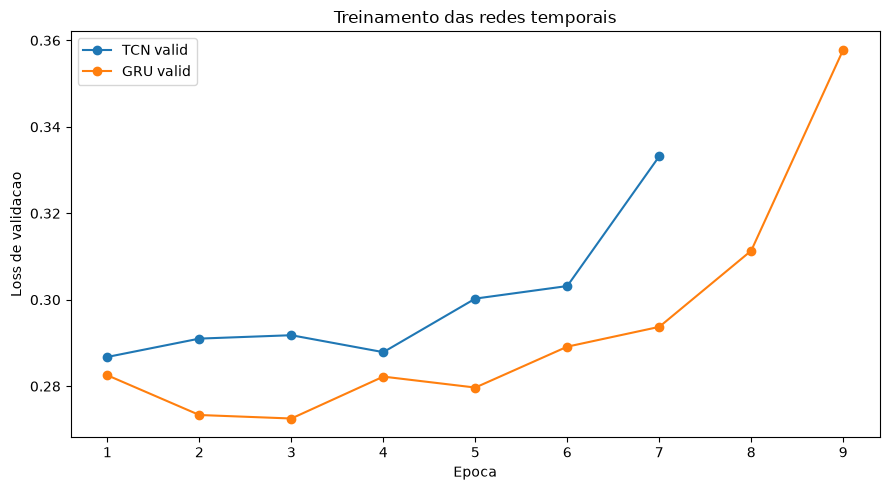

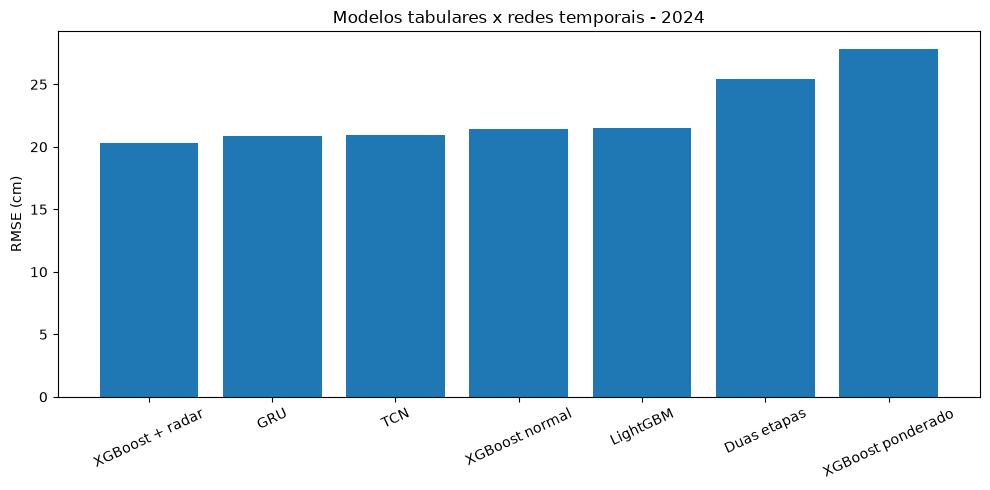

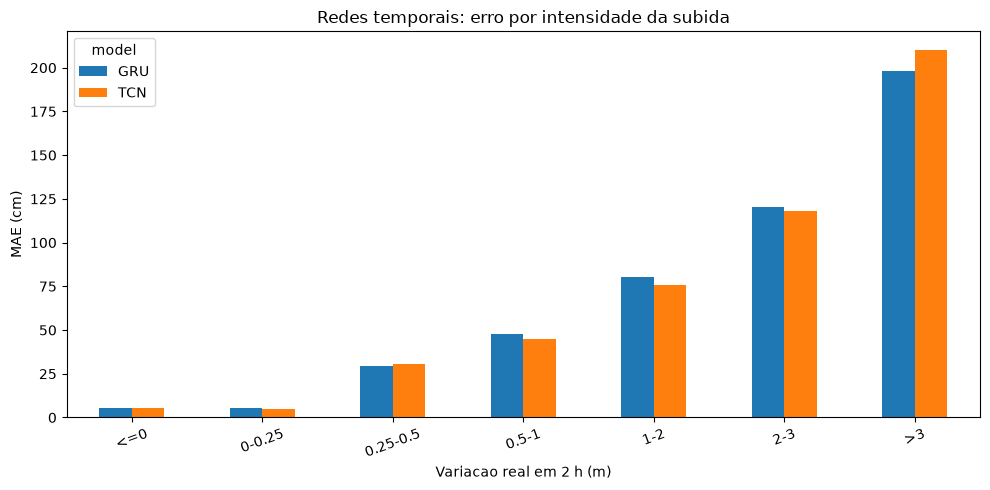

In [13]:
# Curvas de treinamento
fig, ax = plt.subplots(figsize=(9,5))
for name, hist in histories.items():
    ax.plot(hist["epoch"], hist["valid_loss"], marker="o", label=f"{name} valid")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss de validacao")
ax.set_title("Treinamento das redes temporais")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "v6_neural_training_curves.png", dpi=220, bbox_inches="tight")
plt.show()

# RMSE global
if len(comparison):
    fig, ax = plt.subplots(figsize=(10,5))
    z = comparison.sort_values("RMSE_cm")
    ax.bar(z["model"], z["RMSE_cm"])
    ax.set_ylabel("RMSE (cm)")
    ax.set_title("Modelos tabulares x redes temporais - 2024")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    fig.savefig(FIGURES / "v6_neural_vs_tabular_rmse.png", dpi=220, bbox_inches="tight")
    plt.show()

# MAE por faixa somente das redes
pivot = severity_neural.pivot(index="severity_band", columns="model", values="MAE_cm")
order=["<=0","0-0.25","0.25-0.5","0.5-1","1-2","2-3",">3"]
pivot=pivot.reindex(order)
fig, ax = plt.subplots(figsize=(10,5))
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("MAE (cm)")
ax.set_xlabel("Variacao real em 2 h (m)")
ax.set_title("Redes temporais: erro por intensidade da subida")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURES / "v6_neural_mae_by_severity.png", dpi=220, bbox_inches="tight")
plt.show()

## 13. Registro da etapa

O notebook salva os modelos e todas as metricas, mas **nao escolhe automaticamente o modelo que ira para 2025**. Essa decisao fica para o relatorio integrado `07c`, onde modelos tabulares e redes sao comparados juntos.

In [14]:
registry = {
    "created_by": "07b_redes_neurais_temporais.ipynb",
    "horizon_min": HORIZON_MIN,
    "lookback_steps": LOOKBACK_STEPS,
    "lookback_hours": LOOKBACK_STEPS*10/60,
    "input_dim": INPUT_DIM,
    "channel_groups": channel_groups,
    "models_trained": list(predictions.keys()),
    "preprocessor": "models/temporal_preprocessor_v6.json",
    "test_period": "2024 development test",
    "blind_2025_opened": False,
}
(MODELS / "neural_registry_v6.json").write_text(json.dumps(registry, indent=2, ensure_ascii=False), encoding="utf-8")
print("Registro salvo em models/neural_registry_v6.json")

Registro salvo em models/neural_registry_v6.json


## O que fazer depois

Execute agora `07c_relatorio_integrado_2024.ipynb`. Ele produz um relatorio unico e detalhado, em HTML e LaTeX/PDF, explicando:

- o que MAE e RMSE significam em exemplos reais;
- se o erro em `>3 m` e causado apenas pelos poucos casos de 6-7 m ou se ja e grande perto de 3 m;
- datas concretas de acertos e falhas;
- efeitos do radar;
- desempenho por episodio;
- calibracao de incerteza;
- TCN e GRU versus XGBoost + radar;
- recomendacao antes de abrir 2025.